In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


image_path = "input_images/bai3/image.png"

In [ ]:
# Kiểm tra và đọc ảnh
if not os.path.exists(image_path):
    print(f" Vẫn không tìm thấy ảnh!")
    # In ra đường dẫn tuyệt đối để bạn dễ hình dung máy đang tìm ở đâu
    print(f" Máy đang tìm tại: {os.path.abspath(image_path)}")
else:
    # Đọc ảnh xám
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

In [13]:
# Thuật toán nhận diện loại nhiễu
# Đếm các pixel đen tuyệt đối (<=2) và trắng tuyệt đối (>=253)
outlier_ratio = np.sum((img <= 2) | (img >= 253)) / img.size
    
if outlier_ratio > 0.03: # Nếu > 3% là nhiễu muối tiêu
        noise_type = "Salt-and-Pepper"
        filtered_img = cv2.medianBlur(img, 5) # Dùng lọc Trung vị
        filter_name = "Median Filter"
else:
        noise_type = "Gaussian / Other"
        filtered_img = cv2.bilateralFilter(img, 9, 75, 75) # Dùng lọc Song phương
        filter_name = "Bilateral Filter"

In [ ]:
# Tính PSNR (Độ cải thiện chất lượng)
mse = np.mean((img - filtered_img) ** 2)
psnr = 100 if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))

 NHẬN DIỆN XONG!
 Loại nhiễu: Salt-and-Pepper
 Bộ lọc sử dụng: Median Filter
 Chỉ số PSNR: 31.64 dB


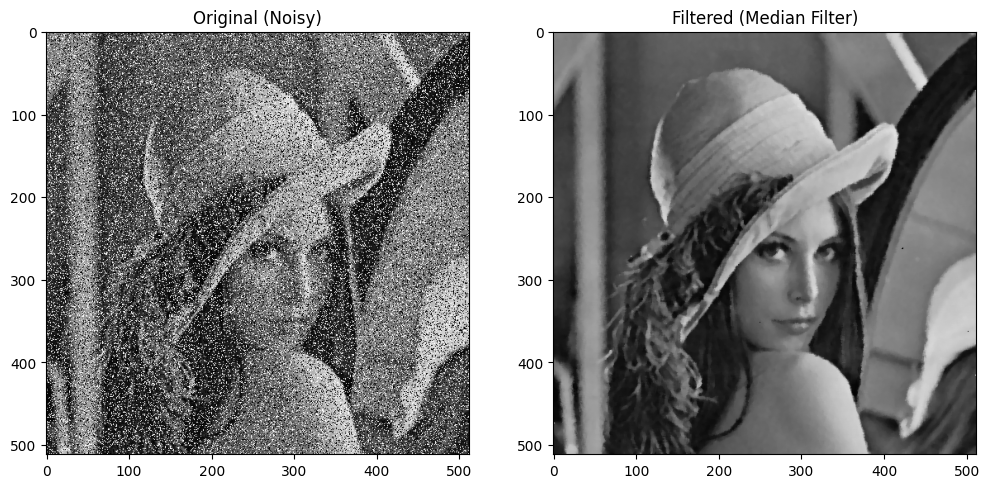

In [22]:
# Xuất báo cáo và hiển thị

print(f" NHẬN DIỆN XONG!")
print(f" Loại nhiễu: {noise_type}")
print(f" Bộ lọc sử dụng: {filter_name}")
print(f" Chỉ số PSNR: {psnr:.2f} dB")

# Hiển thị trực tiếp trong Notebook 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title("Original (Noisy)")
plt.subplot(1, 2, 2); plt.imshow(filtered_img, cmap='gray'); plt.title(f"Filtered ({filter_name})")
plt.show()